<a href="https://colab.research.google.com/github/SadiaFerzeen143/decision-tree-classification-/blob/main/kernel_implementation_and_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [2]:
df = pd.read_csv("breast cancer dataset.csv")

df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [3]:
print("Shape of dataset:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nDataset information:")
df.info()

Shape of dataset: (569, 33)

Columns:
Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   dia

In [4]:
print(df.isnull().sum())

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In [5]:
df["diagnosis"] = df["diagnosis"].map({"M": 1, "B": 0})

print(df["diagnosis"].value_counts())

diagnosis
0    357
1    212
Name: count, dtype: int64


In [6]:
X = df[["radius_mean", "texture_mean"]]

y = df["diagnosis"]

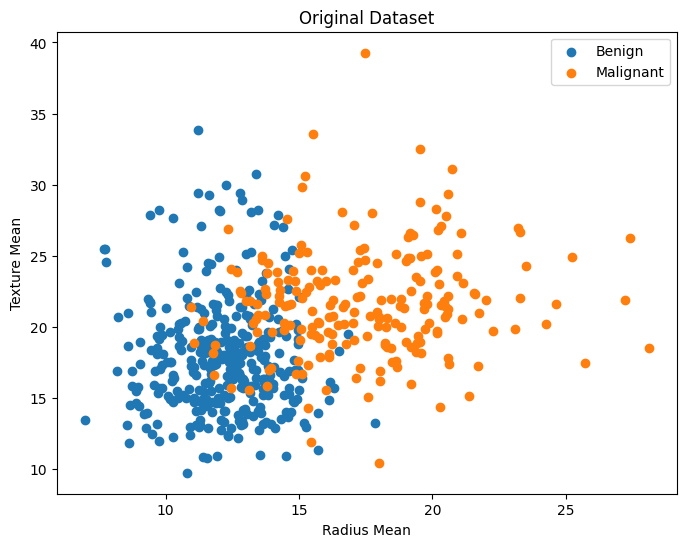

In [7]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X[y == 0]["radius_mean"],
    X[y == 0]["texture_mean"],
    label="Benign"
)

plt.scatter(
    X[y == 1]["radius_mean"],
    X[y == 1]["texture_mean"],
    label="Malignant"
)

plt.xlabel("Radius Mean")
plt.ylabel("Texture Mean")
plt.title("Original Dataset")
plt.legend()
plt.show()

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (455, 2)
Testing data: (114, 2)


In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
linear_model = SVC(kernel="linear")

linear_model.fit(X_train_scaled, y_train)

linear_pred = linear_model.predict(X_test_scaled)

linear_accuracy = accuracy_score(y_test, linear_pred)

print("Linear Kernel Accuracy:", linear_accuracy)

Linear Kernel Accuracy: 0.868421052631579


In [11]:
poly_model = SVC(
    kernel="poly",
    degree=3
)

poly_model.fit(X_train_scaled, y_train)

poly_pred = poly_model.predict(X_test_scaled)

poly_accuracy = accuracy_score(y_test, poly_pred)

print("Polynomial Kernel Accuracy:", poly_accuracy)

Polynomial Kernel Accuracy: 0.7982456140350878


In [12]:
rbf_model = SVC(
    kernel="rbf"
)

rbf_model.fit(X_train_scaled, y_train)

rbf_pred = rbf_model.predict(X_test_scaled)

rbf_accuracy = accuracy_score(y_test, rbf_pred)

print("RBF Kernel Accuracy:", rbf_accuracy)

RBF Kernel Accuracy: 0.9035087719298246


In [13]:
sigmoid_model = SVC(
    kernel="sigmoid"
)

sigmoid_model.fit(X_train_scaled, y_train)

sigmoid_pred = sigmoid_model.predict(X_test_scaled)

sigmoid_accuracy = accuracy_score(y_test, sigmoid_pred)

print("Sigmoid Kernel Accuracy:", sigmoid_accuracy)

Sigmoid Kernel Accuracy: 0.8333333333333334


In [14]:
results = pd.DataFrame({
    "Kernel": [
        "Linear",
        "Polynomial",
        "RBF",
        "Sigmoid"
    ],
    "Accuracy": [
        linear_accuracy,
        poly_accuracy,
        rbf_accuracy,
        sigmoid_accuracy
    ]
})

results

,Kernel,Accuracy
0,Linear,0.868421
1,Polynomial,0.798246
2,RBF,0.903509
3,Sigmoid,0.833333


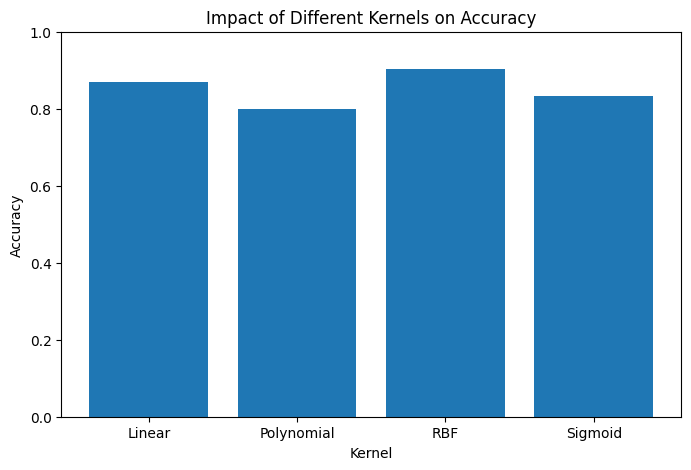

In [15]:
plt.figure(figsize=(8, 5))

plt.bar(
    results["Kernel"],
    results["Accuracy"]
)

plt.xlabel("Kernel")
plt.ylabel("Accuracy")
plt.title("Impact of Different Kernels on Accuracy")

plt.ylim(0, 1)

plt.show()

In [16]:
def plot_decision_boundary(model, X, y, title):

    x_min = X[:, 0].min() - 1
    x_max = X[:, 0].max() + 1

    y_min = X[:, 1].min() - 1
    y_max = X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 500),
        np.linspace(y_min, y_max, 500)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]

    Z = model.predict(grid)

    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 6))

    plt.contourf(xx, yy, Z, alpha=0.3)

    plt.scatter(
        X[:, 0],
        X[:, 1],
        c=y,
        edgecolors="k"
    )

    plt.xlabel("Radius Mean (Scaled)")
    plt.ylabel("Texture Mean (Scaled)")
    plt.title(title)

    plt.show()

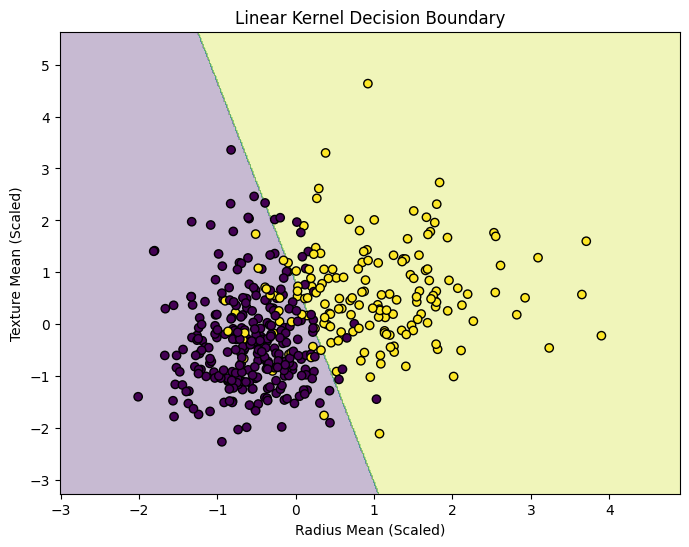

In [17]:
plot_decision_boundary(
    linear_model,
    X_train_scaled,
    y_train,
    "Linear Kernel Decision Boundary"
)

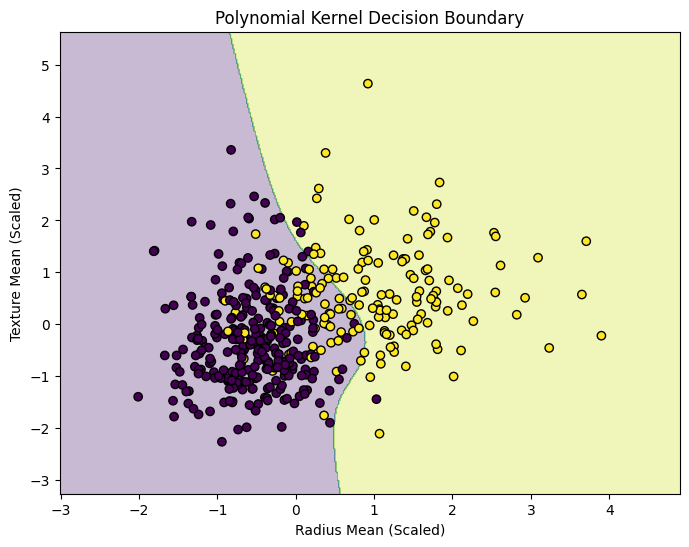

In [18]:
plot_decision_boundary(
    poly_model,
    X_train_scaled,
    y_train,
    "Polynomial Kernel Decision Boundary"
)

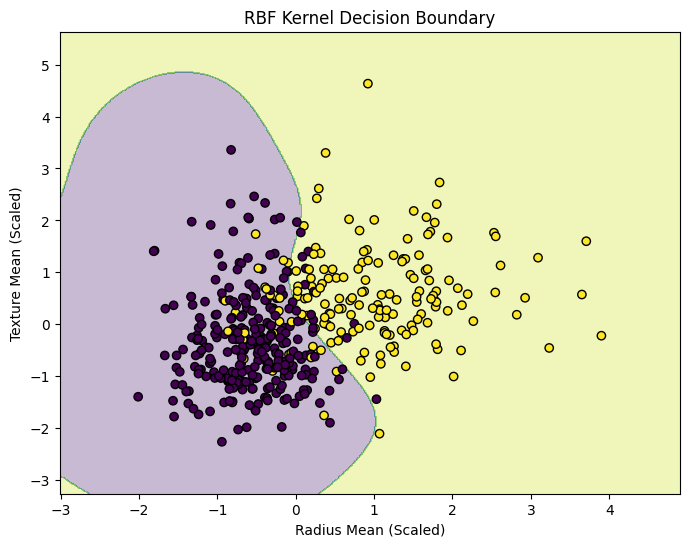

In [19]:
plot_decision_boundary(
    rbf_model,
    X_train_scaled,
    y_train,
    "RBF Kernel Decision Boundary"
)

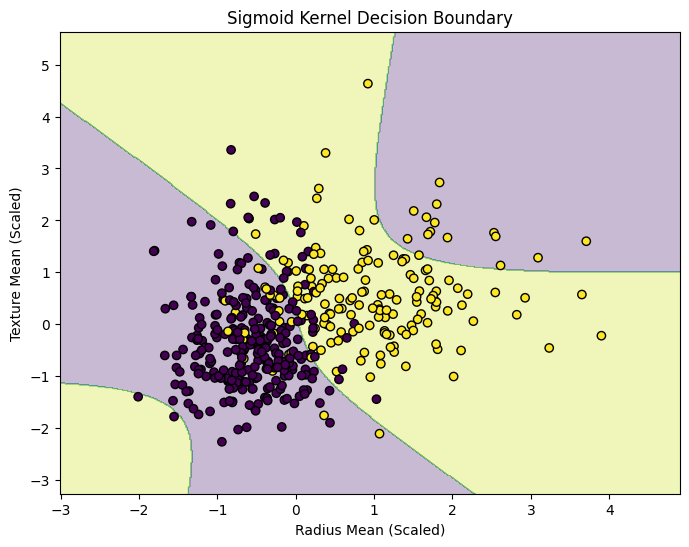

In [20]:
plot_decision_boundary(
    sigmoid_model,
    X_train_scaled,
    y_train,
    "Sigmoid Kernel Decision Boundary"
)

In [21]:
models = {
    "Linear": linear_model,
    "Polynomial": poly_model,
    "RBF": rbf_model,
    "Sigmoid": sigmoid_model
}

evaluation_results = []

for name, model in models.items():

    predictions = model.predict(X_test_scaled)

    evaluation_results.append({
        "Kernel": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1 Score": f1_score(y_test, predictions)
    })

evaluation_df = pd.DataFrame(evaluation_results)

evaluation_df

,Kernel,Accuracy,Precision,Recall,F1 Score
0,Linear,0.868421,0.885714,0.738095,0.805195
1,Polynomial,0.798246,0.913043,0.500000,0.646154
2,RBF,0.903509,1.000000,0.738095,0.849315
3,Sigmoid,0.833333,0.780488,0.761905,0.771084


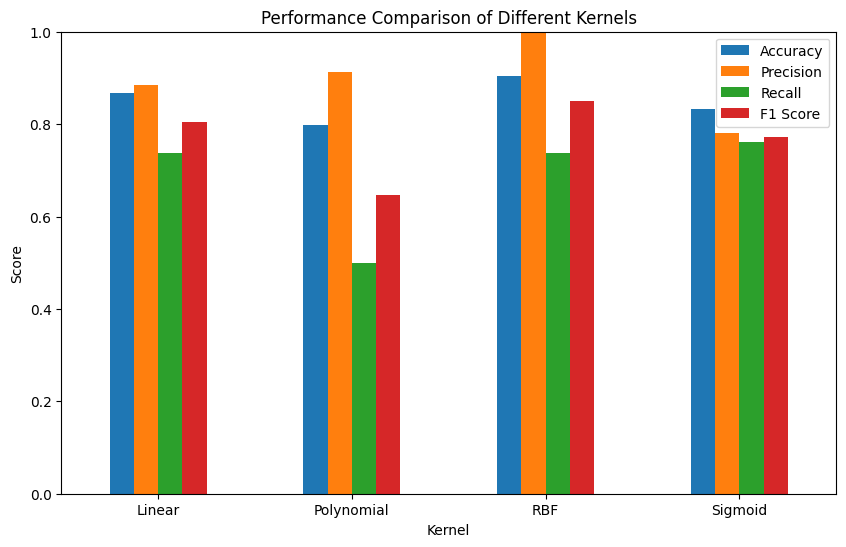

In [22]:
evaluation_df.set_index("Kernel").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Performance Comparison of Different Kernels")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(rotation=0)

plt.show()

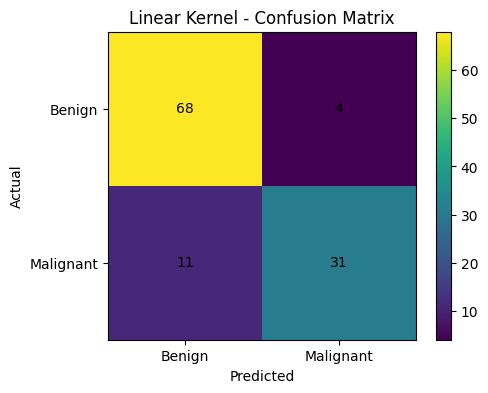

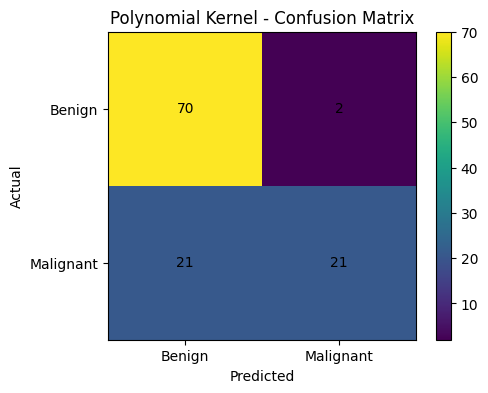

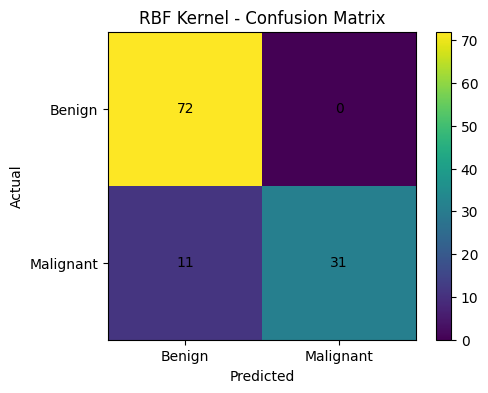

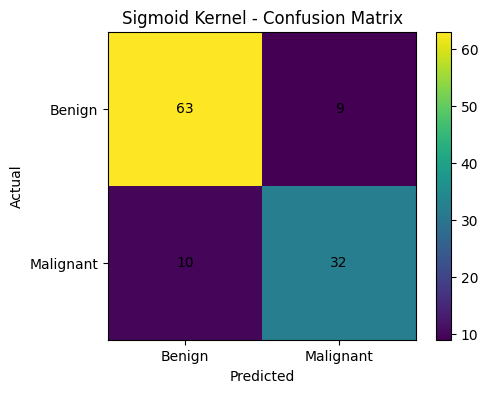

In [23]:
for name, model in models.items():

    predictions = model.predict(X_test_scaled)

    cm = confusion_matrix(y_test, predictions)

    plt.figure(figsize=(5, 4))

    plt.imshow(cm)

    plt.title(f"{name} Kernel - Confusion Matrix")

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.colorbar()

    plt.xticks([0, 1], ["Benign", "Malignant"])
    plt.yticks([0, 1], ["Benign", "Malignant"])

    for i in range(2):
        for j in range(2):
            plt.text(
                j,
                i,
                cm[i, j],
                ha="center",
                va="center"
            )

    plt.show()